In [2]:
import numpy as np
import matplotlib.pyplot as plt

import matplotlib.cm as cm

## 3 Speakers

In [3]:
def simulation_3speaker(l1, l2, l3, s1=1, s2=1, s3=1):
    M = 3
    cl = np.array([l1,l2,l3])
    cs = np.array([s1,s2,s3])

    s = np.array([1,0,0.3])
    s_ind = 0; 
    ds = np.zeros((M,M))
    ds_new = np.zeros((M,M))

    alpha = 0.6

    N = 10^4
    t = np.zeros((N,))
    s_list = np.zeros((len(s),N))
    s_list[:,0] = s
    s_ind_list = np.zeros((N,), dtype=int)
    s_ind_list[0] = s_ind
    ds_list = np.zeros((N,))

    for i in range(N-1):
        tmp = (1-s)/(cl+cs[s_ind])  

        tmp[s_ind] = np.max(tmp)
        deltat = np.min(tmp)
        ind = np.argmin(tmp)
        t[i+1] = t[i] + deltat
        s = alpha * (s + deltat*cl)
        s[s_ind] = 0
        s[ind] = 1

        s_ind = ind
        s_list[:,i+1] = s
        s_ind_list[i+1] = ind

        ds_new[s_ind_list[i],s_ind_list[i+1]] = s_list[s_ind_list[i],i] - s_list[s_ind_list[i+1],i]
        #ds_list[i+1] = np.norm(ds_new-ds)
        ds = ds_new

        dt = np.diff(t)

    return t, cl, cs, dt, s_list, s_ind_list

In [4]:
def plot_3speaker(l1, l2, l3):
    t, cl, cs, dt, s_list, s_ind_list = simulation_3speaker(l1, l2, l3)  # Run simulation


    # Define parameters
    plot_length = 12
    s_prev_list = np.zeros((3, plot_length))
    reset_list = np.zeros(plot_length)

    # Update `s_prev_list` based on `s_ind_list`
    for i in range(plot_length):
        if s_ind_list[i] == 0:
            s_prev_list[0, i] = s_list[0, i] - cs[0] * dt[i]
            s_prev_list[1, i] = s_list[1, i] + cl[1] * dt[i]
            s_prev_list[2, i] = s_list[2, i] + cl[2] * dt[i]
        elif s_ind_list[i] == 1:
            s_prev_list[1, i] = s_list[1, i] - cs[1] * dt[i]
            s_prev_list[0, i] = s_list[0, i] + cl[0] * dt[i]
            s_prev_list[2, i] = s_list[2, i] + cl[2] * dt[i]
        else:
            s_prev_list[2, i] = s_list[2, i] - cs[2] * dt[i]
            s_prev_list[0, i] = s_list[0, i] + cl[0] * dt[i]
            s_prev_list[1, i] = s_list[1, i] + cl[1] * dt[i]

    # Plot setup
    fig, ax = plt.subplots(figsize=(8, 6))

    # Thick line plots
    for i in range(plot_length):
        ax.plot([t[i], t[i+1]], [s_list[0, i], s_prev_list[0, i]], 'b', linewidth=5)
        ax.plot([t[i], t[i+1]], [s_list[1, i], s_prev_list[1, i]], 'r', linewidth=5)
        ax.plot([t[i], t[i+1]], [s_list[2, i], s_prev_list[2, i]], 'g', linewidth=5)

    # Dashed vertical transition lines
    for i in range(plot_length - 1):
        if 0 < s_list[0, i+1] < 1:
            ax.plot([t[i+1], t[i+1]], [s_list[0, i+1], s_prev_list[0, i]], 'b-.', linewidth=3)
        elif 0 < s_list[1, i+1] < 1:
            ax.plot([t[i+1], t[i+1]], [s_list[1, i+1], s_prev_list[1, i]], 'r-.', linewidth=3)
        else:
            ax.plot([t[i+1], t[i+1]], [s_list[2, i+1], s_prev_list[2, i]], 'g-.', linewidth=3)

    for i in range(plot_length):
        current_speaker = s_ind_list[i]
        color = ['b', 'r', 'g'][current_speaker]
        ax.plot([t[i], min(t[i+1],4.5)], [1.02, 1.02], color=color, linewidth=8, transform=ax.get_xaxis_transform(), clip_on=False)

    # Labels and formatting
    ax.set_yticks([0,0.5,1])
    ax.set_xticks([])
    ax.set_xlabel("Time", fontsize=20)
    ax.set_ylabel("Desire to Speak", fontsize=20)
    ax.set_xlim([0, 4.5])

    # Figure settings (similar to MATLAB's print settings)
    fig.tight_layout()
    plt.show()

## N speakers

In [5]:
def simulation(cl, cs):
    M = len(cl)
    #cl = np.array([l1,l2,l3])
    #cs = np.array([1,1,1])

    s = np.random.rand(M)
    s[0] = 1
    s[1] = 0
    s_ind = 0; 
    ds = np.zeros((M,M))
    ds_new = np.zeros((M,M))

    alpha = 0.6

    N = 10**4
    t = np.zeros((N,))
    s_list = np.zeros((len(s),N))
    s_list[:,0] = s
    s_ind_list = np.zeros((N,), dtype=int)
    s_ind_list[0] = s_ind
    ds_list = np.zeros((N,))

    for i in range(N-1):
        tmp = (1-s)/(cl+cs[s_ind])  

        tmp[s_ind] = np.max(tmp)
        deltat = np.min(tmp)
        ind = np.argmin(tmp)
        t[i+1] = t[i] + deltat
        s = alpha * (s + deltat*cl)
        s[s_ind] = 0
        s[ind] = 1

        s_ind = ind
        s_list[:,i+1] = s
        s_ind_list[i+1] = ind

        ds_new[s_ind_list[i],s_ind_list[i+1]] = s_list[s_ind_list[i],i] - s_list[s_ind_list[i+1],i]
        #ds_list[i+1] = np.norm(ds_new-ds)
        ds = ds_new

        dt = np.diff(t)

    return t, cl, cs, dt, s_list, s_ind_list

In [6]:
def plot(cl, cs):
    t, cl, cs, dt, s_list, s_ind_list = simulation(cl, cs)  # Run simulation

    M = len(cl)
    # Define parameters
    plot_length = 15
    s_prev_list = np.zeros((M, plot_length))
    reset_list = np.zeros(plot_length)

            
    for i in range(plot_length):
        k = s_ind_list[i]
        s_prev_list[k] = s_list[k, i] - cs[k] * dt[i]
        for j in range(M):
            if j != k:
                s_prev_list[j, i] = s_list[j, i] + cl[j] * dt[i]
                
    # Plot setup
    fig, ax = plt.subplots(figsize=(8, 6))

    # Thick line plots
    for i in range(plot_length):
        for j in range(M):
            ax.plot([t[i], t[i+1]], [s_list[j, i], s_prev_list[j, i]], 'b', linewidth=5)

    cmap = cm.get_cmap('tab10', M)
    
    for i in range(plot_length):
        current_speaker = s_ind_list[i]
        speaker_color = cmap(s_ind_list[i])
        ax.plot([t[i], min(t[i+1],4.5)], [1.02, 1.02], color=speaker_color, linewidth=8, transform=ax.get_xaxis_transform(), clip_on=False)

    # Labels and formatting
    ax.set_yticks([0,0.5,1])
    ax.set_xticks([])
    ax.set_xlabel("Time", fontsize=20)
    ax.set_ylabel("Desire to Speak", fontsize=20)
    ax.set_xlim([0, 4.5])

    # Figure settings (similar to MATLAB's print settings)
    fig.tight_layout()
    plt.show()

## Demo

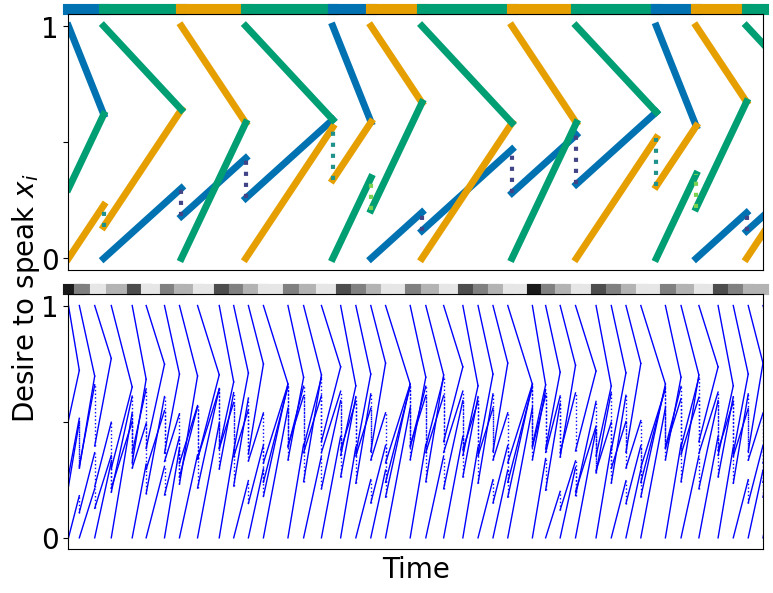

In [7]:
#Plot used in figure

colorblind_palette = {
    'blue':      '#0072B2',
    'orange':    '#E69F00',
    'green':     '#009E73',
    'pink':      '#CC79A7',
    'yellow':    '#F0E442',
    'black':     '#000000'
}


viridis = cm.get_cmap('viridis')
# Choose 3 evenly spaced values between 0 and 1
colorblind_1 = [viridis(i) for i in [0.2, 0.5, 0.8]]

l1, l2, l3 = 0.6,1,1.4
s1, s2, s3 = 1/l1, 1/l2, 1/l3
eps=0.1519
cl = np.array([1-2*eps, 1-eps, 1, 1+eps, 1+2*eps])
cs = 2 - cl
t3, cl3, cs3, dt3, s_list3, s_ind_list3 = simulation_3speaker(l1, l2, l3, s1=s1, s2=s2, s3=s3)
t, cl, cs, dt, s_list, s_ind_list = simulation(cl, cs)


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6))

# First plot (use your plotting logic but target ax1)
# Define parameters
plot_length = 12
s_prev_list = np.zeros((3, plot_length))
reset_list = np.zeros(plot_length)

# Update `s_prev_list` based on `s_ind_list`
for i in range(plot_length):
    if s_ind_list3[i] == 0:
        s_prev_list[0, i] = s_list3[0, i] - cs3[0] * dt3[i]
        s_prev_list[1, i] = s_list3[1, i] + cl3[1] * dt3[i]
        s_prev_list[2, i] = s_list3[2, i] + cl3[2] * dt3[i]
    elif s_ind_list3[i] == 1:
        s_prev_list[1, i] = s_list3[1, i] - cs3[1] * dt3[i]
        s_prev_list[0, i] = s_list3[0, i] + cl3[0] * dt3[i]
        s_prev_list[2, i] = s_list3[2, i] + cl3[2] * dt3[i]
    else:
        s_prev_list[2, i] = s_list3[2, i] - cs3[2] * dt3[i]
        s_prev_list[0, i] = s_list3[0, i] + cl3[0] * dt3[i]
        s_prev_list[1, i] = s_list3[1, i] + cl3[1] * dt3[i]

# Thick line plots
for i in range(plot_length):
    ax1.plot([t3[i], t3[i+1]], [s_list3[0, i], s_prev_list[0, i]], color=colorblind_palette['blue'], linewidth=5)
    ax1.plot([t3[i], t3[i+1]], [s_list3[1, i], s_prev_list[1, i]], color=colorblind_palette['orange'], linewidth=5)
    ax1.plot([t3[i], t3[i+1]], [s_list3[2, i], s_prev_list[2, i]], color=colorblind_palette['green'], linewidth=5)
    #ax1.plot([t3[i], t3[i+1]], [s_list3[0, i], s_prev_list[0, i]], color=colorblind_1[0], linewidth=3)
    #ax1.plot([t3[i], t3[i+1]], [s_list3[1, i], s_prev_list[1, i]], color=colorblind_1[1], linewidth=3)
    #ax1.plot([t3[i], t3[i+1]], [s_list3[2, i], s_prev_list[2, i]], color=colorblind_1[2], linewidth=3)

# Dashed vertical transition lines
for i in range(plot_length - 1):
    if 0 < s_list3[0, i+1] < 1:
        #ax1.plot([t3[i+1], t3[i+1]], [s_list3[0, i+1], s_prev_list[0, i]], '-.', color=colorblind_palette['blue'], linewidth=3)
        ax1.plot([t3[i+1], t3[i+1]], [s_list3[0, i+1], s_prev_list[0, i]], ':', color=colorblind_1[0], linewidth=3)
    elif 0 < s_list3[1, i+1] < 1:
        #ax1.plot([t3[i+1], t3[i+1]], [s_list3[1, i+1], s_prev_list[1, i]], '-.', color=colorblind_palette['orange'], linewidth=3)
        ax1.plot([t3[i+1], t3[i+1]], [s_list3[1, i+1], s_prev_list[1, i]], ':', color=colorblind_1[1], linewidth=3)
    else:
        #ax1.plot([t3[i+1], t3[i+1]], [s_list3[2, i+1], s_prev_list[2, i]], '-.', color=colorblind_palette['green'], linewidth=3)
        ax1.plot([t3[i+1], t3[i+1]], [s_list3[2, i+1], s_prev_list[2, i]], ':', color=colorblind_1[2], linewidth=3)

for i in range(plot_length):
    current_speaker = s_ind_list3[i]
    color = [colorblind_palette['blue'], colorblind_palette['orange'], colorblind_palette['green']][current_speaker]
    #color = [colorblind_1[0], colorblind_1[1], colorblind_1[2]][current_speaker]
    ax1.plot([t3[i], min(t3[i+1],4.5)], [1.02, 1.02], color=color, linewidth=8, transform=ax1.get_xaxis_transform(), clip_on=False)

# Labels and formatting
ax1.set_yticks([0,0.5,1])
ax1.set_yticklabels([0, '', 1], fontsize=20)
ax1.set_xticks([])
#ax1.set_xlabel("Time", fontsize=20)
#ax1.set_ylabel("Desire to Speak", fontsize=20)
ax1.set_xlim([0, 4.5])

# Second plot (use second dataset and same approach)
M = len(cl)
# Define parameters
#plot_length = 15
plot_length = 42
s_prev_list = np.zeros((M, plot_length))
reset_list = np.zeros(plot_length)


for i in range(plot_length):
    k = s_ind_list[i]
    s_prev_list[k, i] = s_list[k, i] - cs[k] * dt[i]
    for j in range(M):
        if j != k:
            s_prev_list[j, i] = s_list[j, i] + cl[j] * dt[i]

# Thick line plots
for i in range(plot_length):
    for j in range(M):
        ax2.plot([t[i], t[i+1]], [s_list[j, i], s_prev_list[j, i]], 'b', linewidth=1)

#cmap = cm.get_cmap('tab10', M)
grays = ['0.1', '0.3', '0.5', '0.7', '0.9']  # dark to light

for i in range(plot_length-1):
    current_speaker = s_ind_list[i]
    speaker_color = grays[s_ind_list[i]]
    #ax2.plot([t[i], min(t[i+1],4.5)], [1.02, 1.02], color=speaker_color, linewidth=8, transform=ax2.get_xaxis_transform(), clip_on=False)
    ax2.plot([t[i], min(t[i+1],15.5)], [1.02, 1.02], color=speaker_color, linewidth=8, transform=ax2.get_xaxis_transform(), clip_on=False)

for i in range(plot_length - 1):
    if 0 < s_list[0, i+1] < 1:
        ax2.plot([t[i+1], t[i+1]], [s_list[0, i+1], s_prev_list[0, i]], 'b:', linewidth=1)
    if 0 < s_list[1, i+1] < 1:
        ax2.plot([t[i+1], t[i+1]], [s_list[1, i+1], s_prev_list[1, i]], 'b:', linewidth=1)
    if 0 < s_list[2, i+1] < 1:
        ax2.plot([t[i+1], t[i+1]], [s_list[2, i+1], s_prev_list[2, i]], 'b:', linewidth=1)
    if 0 < s_list[3, i+1] < 1:
        ax2.plot([t[i+1], t[i+1]], [s_list[3, i+1], s_prev_list[3, i]], 'b:', linewidth=1)   
    if 0 < s_list[4, i+1] < 1:
        ax2.plot([t[i+1], t[i+1]], [s_list[4, i+1], s_prev_list[4, i]], 'b:', linewidth=1)

# Labels and formatting
ax2.set_yticks([0,0.5,1])
ax2.set_yticklabels([0, '', 1], fontsize=20)
ax2.set_xticks([])
ax2.set_xlabel("Time", fontsize=20)
#ax2.set_ylabel("Desire to Speak", fontsize=20)
#ax2.set_xlim([0, min(t[i+1],4.5)])
ax2.set_xlim([0, min(t[i+1],15.5)])

fig.text(0.04, 0.5, 'Desire to speak $x_i$', va='center', rotation='vertical', fontsize=20)
fig.tight_layout(rect=[0.06, 0, 1, 1])
plt.show()